In [1]:
!pip install -q numpy pandas matplotlib seaborn scikit-learn joblib

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:

# Cell 2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import joblib
import warnings
warnings.filterwarnings("ignore")

# output dirs
OUT = "output"
FIGS = os.path.join(OUT, "figs")
MODELS = os.path.join(OUT, "models")
os.makedirs(FIGS, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

sns.set(style="whitegrid")
print("Output folders:", OUT, FIGS, MODELS)


Output folders: output output\figs output\models


In [3]:
# Cell 3
df = pd.read_csv("heart.csv")   # file in same folder as notebook
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()


Shape: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


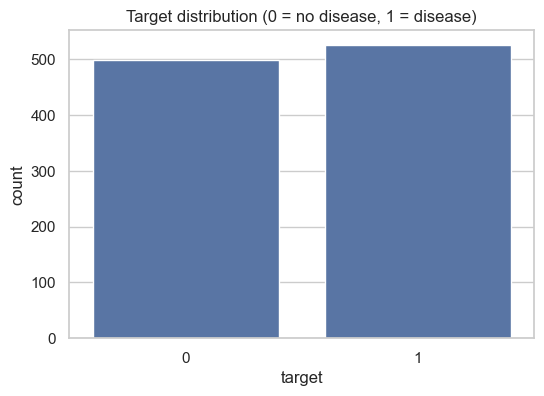

In [4]:
# Cell 4
print(df.info())
display(df.describe().T)

plt.figure(figsize=(6,4))
sns.countplot(x="target", data=df)
plt.title("Target distribution (0 = no disease, 1 = disease)")
plt.savefig(os.path.join(FIGS, "target_distribution.png"), bbox_inches="tight")
plt.show()


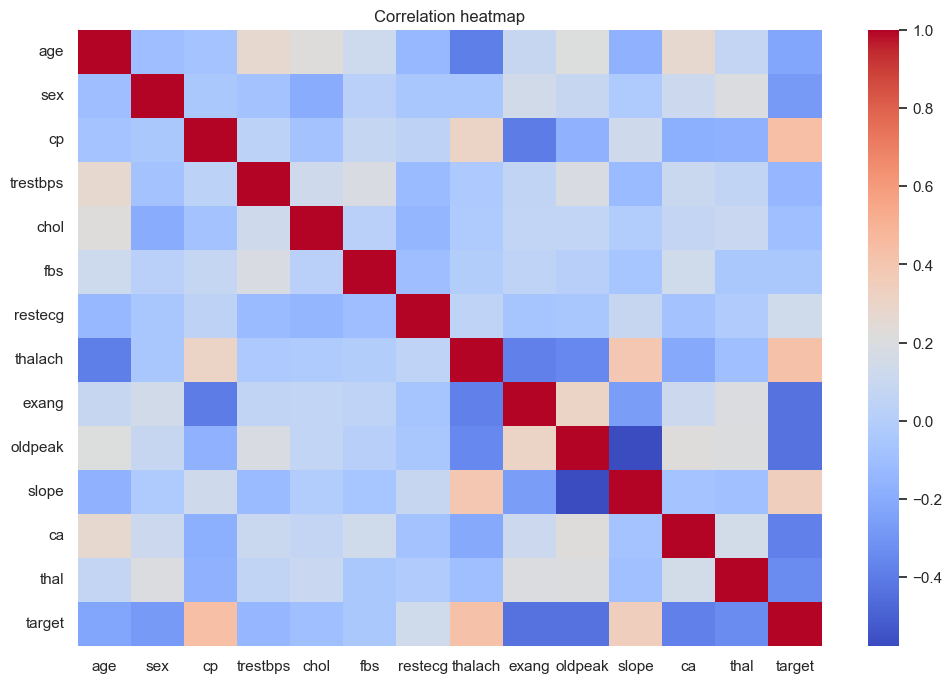

In [5]:
# Cell 5
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.savefig(os.path.join(FIGS, "correlation_heatmap.png"), bbox_inches="tight")
plt.show()


In [6]:
# Cell 6
# Identify numeric columns and check nulls
print("Nulls per column:\n", df.isna().sum())

# If there are missing values (many heart datasets have none), fill safely:
for col in df.columns:
    if df[col].isna().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

# Features & target
X = df.drop("target", axis=1)
y = df["target"]

# Optional: convert categorical columns if present (some versions have 'thal' as categorical)
# Example:
# if X['thal'].dtype == object:
#     X['thal'] = X['thal'].map({'normal':0,'fixed_defect':1,'reversible_defect':2})

print("X shape:", X.shape, "y shape:", y.shape)
display(X.head())


Nulls per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
X shape: (1025, 13) y shape: (1025,)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [7]:
# Cell 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Save scaler (optional)
joblib.dump(scaler, os.path.join(MODELS, "scaler.joblib"))
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (820, 13) Test shape: (205, 13)


In [8]:
# Cell 8
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(probability=True, kernel="rbf", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

fitted = {}
for name, model in models.items():
    # use scaled data for models that need it (LR, SVM, KNN). RandomForest works with raw but scaled is fine.
    if name in ("RandomForest",):
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    fitted[name] = (model, acc)
    print(f"{name:18s} Accuracy: {acc:.4f}")


LogisticRegression Accuracy: 0.8098
RandomForest       Accuracy: 1.0000
SVM                Accuracy: 0.9268
KNN                Accuracy: 0.8439


In [9]:
# Cell 9
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, (model, _) in fitted.items():
    # choose correct input for model
    X_all = X.values if name == "RandomForest" else scaler.transform(X)
    scores = cross_val_score(model, X_all, y, cv=cv, scoring="accuracy")
    print(f"{name:18s} CV mean={scores.mean():.4f} std={scores.std():.4f}")


LogisticRegression CV mean=0.8459 std=0.0150
RandomForest       CV mean=0.9961 std=0.0078
SVM                CV mean=0.9210 std=0.0125
KNN                CV mean=0.8429 std=0.0104


Best model: RandomForest with test accuracy 1.0
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



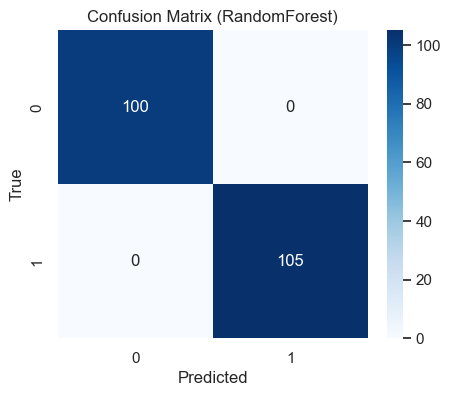

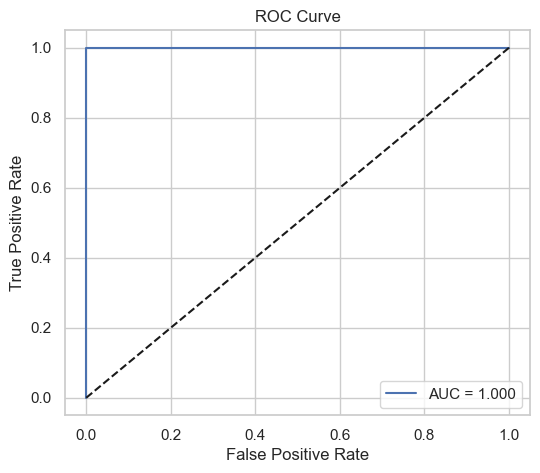

Saved model: output\models\best_heart_model_RandomForest.joblib


In [10]:
# Cell 10
# pick model with highest accuracy on test
best_name, best_acc = max(((n, acc) for n, (_, acc) in fitted.items()), key=lambda x: x[1])
best_model = fitted[best_name][0]
print("Best model:", best_name, "with test accuracy", best_acc)

# Use appropriate X for predictions
if best_name == "RandomForest":
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:,1] if hasattr(best_model, "predict_proba") else None
else:
    y_pred = best_model.predict(X_test_scaled)
    y_proba = best_model.predict_proba(X_test_scaled)[:,1] if hasattr(best_model, "predict_proba") else None

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="g", cmap="Blues")
plt.title(f"Confusion Matrix ({best_name})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(os.path.join(FIGS, "confusion_matrix.png"), bbox_inches="tight")
plt.show()

# ROC if probabilities exist
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.savefig(os.path.join(FIGS, "roc_curve.png"), bbox_inches="tight")
    plt.show()

# Save model and metadata
joblib.dump({"name": best_name, "model": best_model, "scaler": scaler, "features": list(X.columns)}, os.path.join(MODELS, f"best_heart_model_{best_name}.joblib"))
print("Saved model:", os.path.join(MODELS, f"best_heart_model_{best_name}.joblib"))


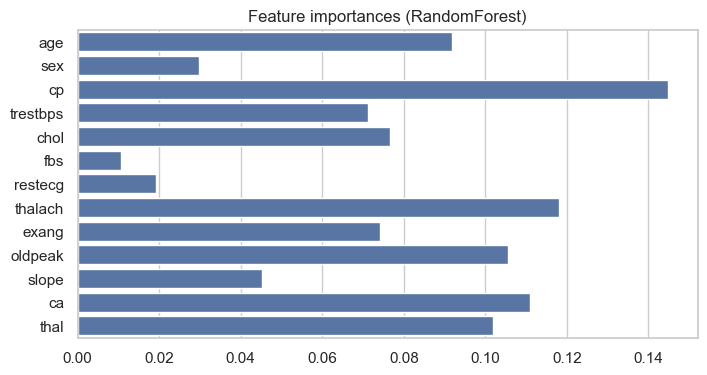

In [11]:
# Cell 11
features = X.columns.tolist()
plt.figure(figsize=(8,4))
if best_name in ("RandomForest",):
    importances = best_model.feature_importances_
    sns.barplot(x=importances, y=features)
    plt.title("Feature importances (RandomForest)")
    plt.savefig(os.path.join(FIGS, "feature_importances.png"), bbox_inches="tight")
    plt.show()
elif best_name == "LogisticRegression":
    coefs = best_model.coef_.ravel()
    sns.barplot(x=np.abs(coefs), y=features)
    plt.title("Mean |coef| per feature (Logistic Regression)")
    plt.savefig(os.path.join(FIGS, "feature_coefs.png"), bbox_inches="tight")
    plt.show()
else:
    print("Feature importance not available for", best_name)


In [12]:
# Cell 12
report = f"""
Heart Disease Prediction Report
Best model: {best_name}
Test accuracy: {accuracy_score(y_test, y_pred):.4f}
Classification report:
{classification_report(y_test, y_pred)}
"""
open(os.path.join(OUT, "report.txt"), "w").write(report)
print("Report written to", os.path.join(OUT, "report.txt"))
print(report)


Report written to output\report.txt

Heart Disease Prediction Report
Best model: RandomForest
Test accuracy: 1.0000
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205




numpy
pandas
matplotlib
seaborn
scikit-learn
joblib
